In [1]:
import os, sys
import scanpy as sc


In [2]:
os.getcwd()

'/Users/stanleydale/user_generated/breault-lab/single-cell/notebooks/D2_Lapa'

In [3]:
os.chdir('../../analysis')
sys.path.append('../src')
from utils import cell_type_markers

In [4]:
## include a scanpy save directory for the figures

In [5]:
os.getcwd()

'/Users/stanleydale/user_generated/breault-lab/single-cell/analysis'

In [6]:
os.chdir('../analysis')

In [7]:
d2_lapa = sc.read_h5ad('clustered_egfDuod_D2_Lapa_DZ.h5ad')

In [8]:
d2_lapa

AnnData object with n_obs × n_vars = 60337 × 28941
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

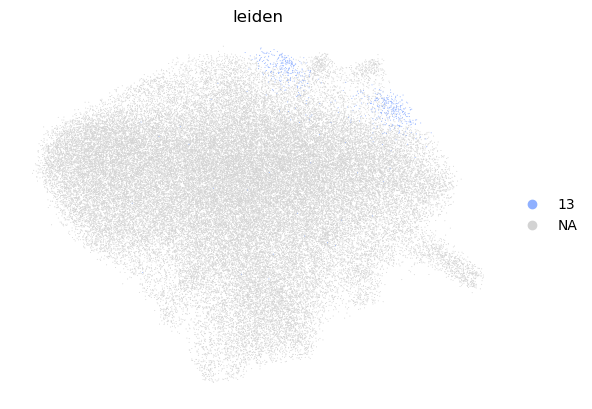

In [9]:
sc.pl.umap(
    d2_lapa,
    color="leiden",
    palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    groups=["13"],
    frameon=False
)

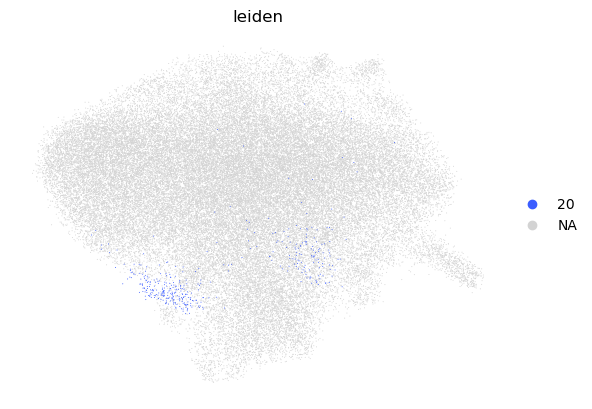

In [10]:
sc.pl.umap(
    d2_lapa,
    color="leiden",
    palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    groups=["20"],
    frameon=False
)

## These are our goblet cells, cluster 20

### Let's identify our secretory PCs

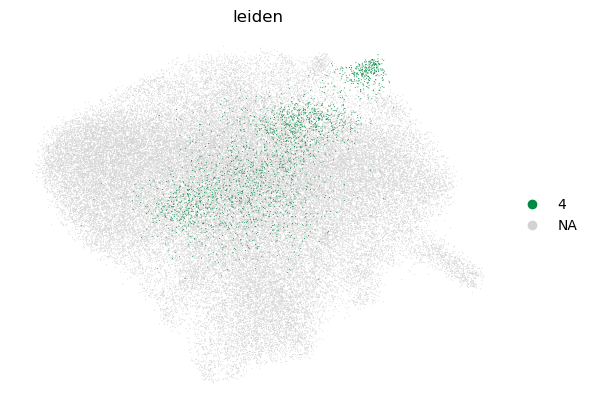

In [11]:
sc.pl.umap(
    d2_lapa,
    color="leiden",
    palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    groups=["4"],
    frameon=False
)

### Cluster 4 is our set of secretory PCs

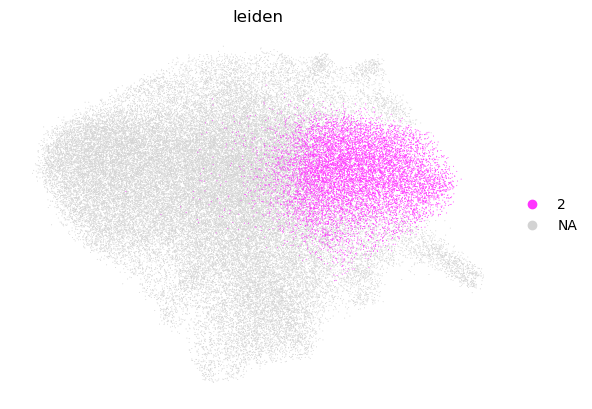

In [12]:
sc.pl.umap(
    d2_lapa,
    color="leiden",
    palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    groups=["2"],
    frameon=False
)

In [13]:

d2_lapa.obs['manual_labelled'] = d2_lapa.obs['leiden'].copy()

In [19]:
d2_lapa_map = {
    "1": "PCs",
    "0": "ISCs",
    "4": "Proliferating progenitor cells",
    "2": "Secretory progenitor cells",
    "3": "Enterocytes",
    "6": "Inflammed progenitor cells",
}

In [20]:
d2_lapa.obs["manual_label"] = "PCs"

In [21]:
for cl, lab in d2_lapa_map.items():
    sel = d2_lapa.obs["leiden"] == cl
    d2_lapa.obs.loc[sel, "manual_label"] = lab

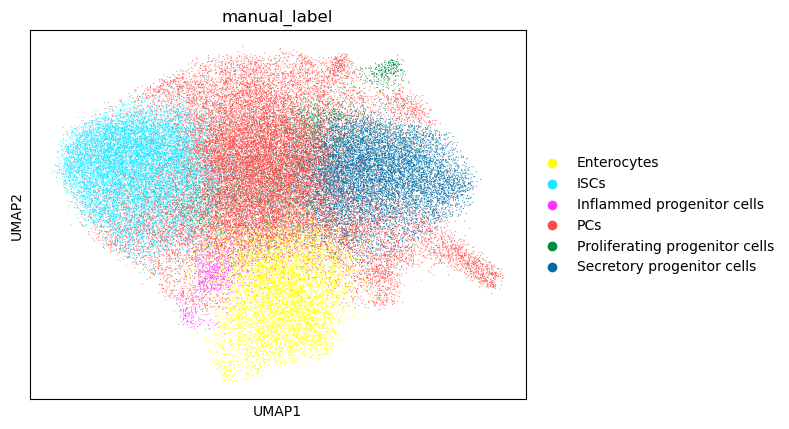

In [22]:
sc.pl.umap(d2_lapa, color = 'manual_label', palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
)

In [ ]:
### I might flip the ISCs and the PC labels
## I flipped these!

In [23]:
sc.write('manual_labelled/d2_lapa_manual_labels.h5ad', d2_lapa)